# Hidden Markov Model Regime Construction

This notebook constructs market-regime features using a Gaussian Hidden Markov Model (HMM). The HMM is not used as a standalone classifier for next-day WTI direction. Instead, it is used as an unsupervised feature engineering step that converts macroeconomic variables, price-derived market-state variables, and CFTC/COT positioning variables into regime labels and regime probabilities.

The final supervised forecasting models use these regime outputs as additional predictors. This allows the models to condition their predictions on the broader market environment, such as whether the oil market is in a high-volatility, trending, stressed, or positioning-driven state.

In [3]:
import pandas as pd
import numpy as np

# Load the merged modeling dataset created after adding the CFTC/COT features.
df_2 = pd.read_csv("full_dataset.csv")

# Convert the Date column to a datetime index so all splits are chronological.
df_2["Date"] = pd.to_datetime(df_2["Date"])
df_2 = df_2.sort_values("Date").set_index("Date")

print("Shape:", df_2.shape)
print("\nDate range:", df_2.index.min(), df_2.index.max())

print("\nColumns:", df_2.columns)
print(df_2.columns.tolist())

print("\nDuplicate dates:", df_2.index.duplicated().sum())
print("Is sorted:", df_2.index.is_monotonic_increasing)

missing = df_2.isna().sum()
print("\nMissing values:")
print(missing[missing > 0])

# ------------------------
# TARGET CHECK
# ------------------------

print("\nTarget distribution:")
print(df_2["Target"].value_counts())
print(df_2["Target"].value_counts(normalize=True))

# ------------------------
# TARGET VALIDATION
# ------------------------

check = df_2[["Price", "Target"]].copy()
check["next_price"] = check["Price"].shift(-1)
check["manual_target"] = (check["next_price"] > check["Price"]).astype(int)

mismatch = (check.iloc[:-1]["Target"] != check.iloc[:-1]["manual_target"]).sum()

print("\nTarget mismatches:", mismatch)

Shape: (2749, 46)

Date range: 2015-05-21 00:00:00 2025-10-31 00:00:00

Columns: Index(['Price', 'macro_month', 'RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS',
       'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio',
       'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA',
       'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM',
       'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM',
       'UMCSENTx', 'Target', 'net_position', 'net_position_pct', 'flow',
       'long_short_ratio', 'Open_Interest_All', 'oi_change', 'returns',
       'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend'],
      dtype='object')
['Price', 'macro_month', 'RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUS

Examining some basic returns and volatility plots. The return and volatility series exhibit clear heteroskedasticity and regime-like behavior, particularly during periods of market stress such as 2020.

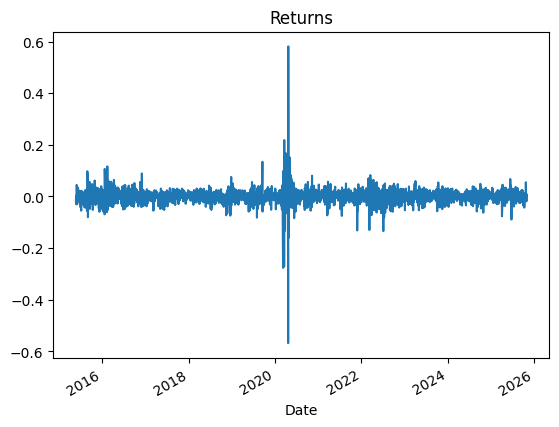

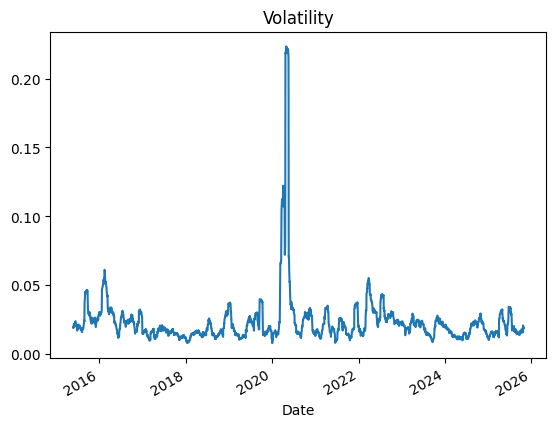

In [5]:
import matplotlib.pyplot as plt

# Converting my returns to log returns
df_2["returns"] = np.log(df_2["Price"]).diff()
df_2 = df_2.dropna()

df_2["returns"].plot(title="Returns")
plt.show()

df_2["vol_20"].plot(title="Volatility")
plt.show()

## 2. Define HMM Feature Blocks

The HMM uses three groups of features: macroeconomic variables, price-derived market-state variables, and CFTC/COT positioning variables. I separate the features into blocks so that each group can be scaled and compressed independently before fitting the HMM.

The final model intentionally does not include raw WTI price levels or a full 30-day sequence of raw price lags. Instead, recent price behavior is represented through log returns, rolling volatility, rolling momentum, drawdown, and trend. This keeps the regime model focused on broader market states rather than allowing it to depend heavily on raw autoregressive price patterns.

In [7]:
macro_cols = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx",
    "EXCAUSx", "PPICMM", "UMCSENTx"
]

market_cols = [
    "returns", "vol_20", "momentum_20", "vol_60", "drawdown", "trend"
]

cot_cols = [
    "net_position", "net_position_pct", "flow",
    "long_short_ratio", "Open_Interest_All", "oi_change"
]

In [8]:
# Confirm that all required HMM input columns are present.
required_cols = macro_cols + market_cols + cot_cols
missing_cols = [col for col in required_cols if col not in df_2.columns]

if missing_cols:
    raise ValueError(f"Missing required HMM columns: {missing_cols}")

print("Number of macro features:", len(macro_cols))
print("Number of market-state features:", len(market_cols))
print("Number of COT features:", len(cot_cols))

Number of macro features: 31
Number of market-state features: 6
Number of COT features: 6


## 3. Chronological Train, Validation, and Test Split

The HMM is fit using only the training period. Validation data is used to compare HMM specifications, while the test period is held out for final evaluation. The split is chronological because this is a time-series forecasting problem, and shuffling would allow future market conditions to influence earlier training observations.

In [104]:
train_end = "2021-12-31"
val_end = "2023-12-31"

train_df_raw = df_2.loc[:train_end].copy()

val_df_raw = df_2.loc[train_end:val_end].copy()
val_df_raw = val_df_raw.iloc[1:]

test_df_raw = df_2.loc[val_end:].copy()
test_df_raw = test_df_raw.iloc[1:]

print("Train shape:", train_df_raw.shape)
print("Val shape:", val_df_raw.shape)
print("Test shape:", test_df_raw.shape)

print("\nDate ranges:")
print("Train:", train_df_raw.index.min(), "→", train_df_raw.index.max())
print("Val:", val_df_raw.index.min(), "→", val_df_raw.index.max())
print("Test:", test_df_raw.index.min(), "→", test_df_raw.index.max())

Train shape: (1744, 46)
Val shape: (529, 46)
Test shape: (475, 46)

Date ranges:
Train: 2015-05-21 00:00:00 → 2021-12-31 00:00:00
Val: 2022-01-03 00:00:00 → 2023-12-29 00:00:00
Test: 2024-01-02 00:00:00 → 2025-10-31 00:00:00


## 4. Scale Each Feature Block Using Training Data Only

Each feature block is standardized separately. This matters because macro variables, price-derived variables, and COT contract counts are measured on very different scales. The scalers are fit only on the training set and then applied to validation and test data to avoid data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit scalers on training data only.
macro_scaler = StandardScaler()
market_scaler = StandardScaler()
cot_scaler = StandardScaler()

X_train_macro = macro_scaler.fit_transform(train_df_raw[macro_cols])
X_val_macro = macro_scaler.transform(val_df_raw[macro_cols])
X_test_macro = macro_scaler.transform(test_df_raw[macro_cols])

X_train_market = market_scaler.fit_transform(train_df_raw[market_cols])
X_val_market = market_scaler.transform(val_df_raw[market_cols])
X_test_market = market_scaler.transform(test_df_raw[market_cols])

X_train_cot = cot_scaler.fit_transform(train_df_raw[cot_cols])
X_val_cot = cot_scaler.transform(val_df_raw[cot_cols])
X_test_cot = cot_scaler.transform(test_df_raw[cot_cols])

## 5. Inspect PCA Dimensionality by Feature Block

Before fitting the HMM, I inspect the cumulative explained variance for each feature block. PCA reduces the dimensionality of the macro, market-state, and COT blocks while preserving most of their variation. This helps the HMM fit more stable regimes instead of estimating state distributions in a high-dimensional raw feature space.

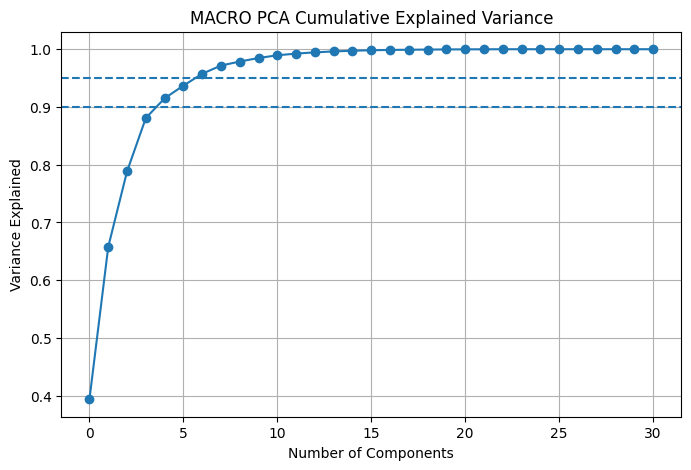

macro
Components for 90% variance: 5
Components for 95% variance: 7



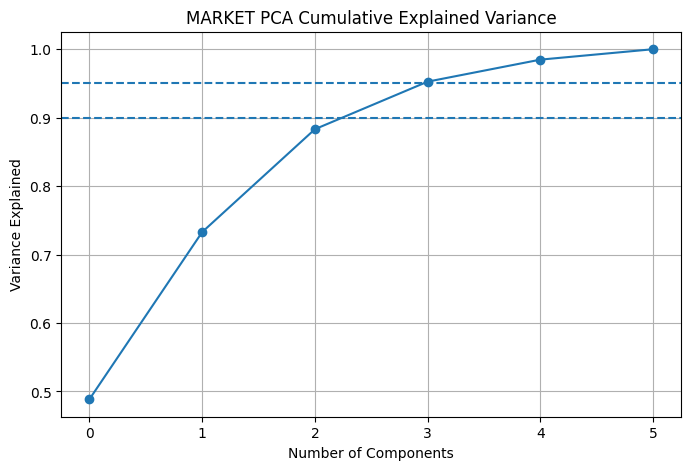

market
Components for 90% variance: 4
Components for 95% variance: 4



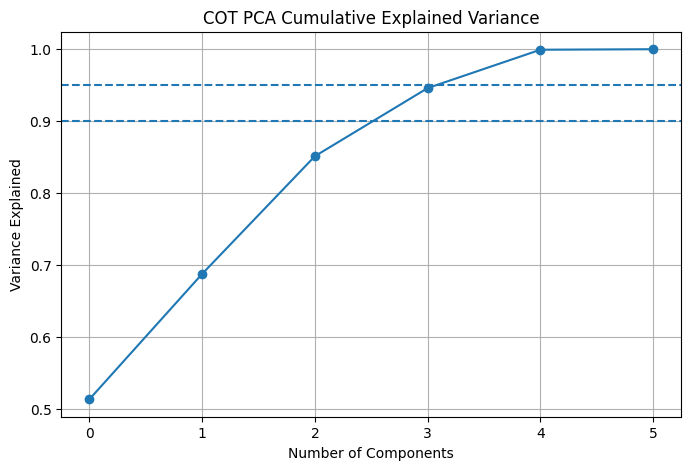

cot
Components for 90% variance: 4
Components for 95% variance: 5



In [106]:
from sklearn.decomposition import PCA

for name, X in [
    ("macro", X_train_macro),
    ("market", X_train_market),
    ("cot", X_train_cot)
]:
    pca_full = PCA()
    pca_full.fit(X)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    plt.figure(figsize=(8, 5))
    plt.plot(cumulative_variance, marker="o")
    plt.axhline(0.90, linestyle="--")
    plt.axhline(0.95, linestyle="--")
    plt.title(f"{name.upper()} PCA Cumulative Explained Variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Variance Explained")
    plt.grid()
    plt.show()

    k_90 = np.argmax(cumulative_variance >= 0.90) + 1
    k_95 = np.argmax(cumulative_variance >= 0.95) + 1

    print(name)
    print("Components for 90% variance:", k_90)
    print("Components for 95% variance:", k_95)
    print()

## 6. Tune the HMM Regime Specification

This section compares HMM specifications across the number of PCA components, number of regimes, covariance structure, minimum covariance value, transition prior, inference algorithm, and random seed. I evaluate models using validation log-likelihood per observation while also checking regime balance. This avoids selecting a model that has high likelihood but collapses most observations into one regime.

In [ ]:
from hmmlearn.hmm import GaussianHMM

# pca tuning grid is based on the cumulative variance plots above, but I also want to try a few extra values just to be safe.
# Explained variance is helpful, but may not end up being the most important factor in terms of HMM performance, so I want to be flexible.
pca_options = [2, 3, 4, 5, 6]
# I did not want to use too many regimes because it would make interpretation more difficult, and I also wanted to avoid very small regimes
regime_options = [2, 3, 4]
cov_options = ["spherical", "diag", "tied"]
min_covar_options = [1e-3, 1e-2, 1e-1]
transmat_prior_options = [1.0, 5.0, 10.0]
algorithm_options = ["map", "viterbi"]
seeds = [0, 1, 2, 3, 4, 5, 10, 42]

macro_weight = 1 / np.sqrt(30.44)
market_weight = 1.0
cot_weight = 1 / np.sqrt(7)

results = []

for n_pca in pca_options:

    # Do not use more PCA components than a block actually has
    n_macro = min(n_pca, X_train_macro.shape[1])
    n_market = min(n_pca, X_train_market.shape[1])
    n_cot = min(n_pca, X_train_cot.shape[1])

    macro_pca = PCA(n_components=n_macro)
    market_pca = PCA(n_components=n_market)
    cot_pca = PCA(n_components=n_cot)

    X_train_macro_pca = macro_pca.fit_transform(X_train_macro)
    X_val_macro_pca = macro_pca.transform(X_val_macro)

    X_train_market_pca = market_pca.fit_transform(X_train_market)
    X_val_market_pca = market_pca.transform(X_val_market)

    X_train_cot_pca = cot_pca.fit_transform(X_train_cot)
    X_val_cot_pca = cot_pca.transform(X_val_cot)

    X_train_hmm = np.hstack([
        macro_weight * X_train_macro_pca,
        market_weight * X_train_market_pca,
        cot_weight * X_train_cot_pca
    ])

    X_val_hmm = np.hstack([
        macro_weight * X_val_macro_pca,
        market_weight * X_val_market_pca,
        cot_weight * X_val_cot_pca
    ])

    for n_regimes in regime_options:
        for cov_type in cov_options:
            for min_covar in min_covar_options:
                for trans_prior in transmat_prior_options:
                    for algorithm in algorithm_options:

                        best_model = None
                        best_seed = None
                        best_train_score = -np.inf

                        for seed in seeds:
                            try:
                                hmm = GaussianHMM(
                                    n_components=n_regimes,
                                    covariance_type=cov_type,
                                    min_covar=min_covar,
                                    transmat_prior=trans_prior,
                                    startprob_prior=1.0,
                                    n_iter=1000,
                                    tol=1e-4,
                                    algorithm=algorithm,
                                    random_state=seed
                                )

                                hmm.fit(X_train_hmm)
                                train_score = hmm.score(X_train_hmm)

                                if train_score > best_train_score:
                                    best_train_score = train_score
                                    best_model = hmm
                                    best_seed = seed

                            except Exception:
                                continue

                        if best_model is None:
                            continue

                        try:
                            val_score = best_model.score(X_val_hmm)

                            train_regime = best_model.predict(X_train_hmm)
                            val_regime = best_model.predict(X_val_hmm)

                            train_counts = np.bincount(train_regime, minlength=n_regimes)
                            val_counts = np.bincount(val_regime, minlength=n_regimes)

                            results.append({
                                "n_pca": n_pca,
                                "n_macro_pca": n_macro,
                                "n_market_pca": n_market,
                                "n_cot_pca": n_cot,
                                "n_regimes": n_regimes,
                                "covariance_type": cov_type,
                                "min_covar": min_covar,
                                "transmat_prior": trans_prior,
                                "algorithm": algorithm,
                                "best_seed": best_seed,
                                "train_score": best_train_score,
                                "val_score": val_score,
                                "train_score_per_obs": best_train_score / len(X_train_hmm),
                                "val_score_per_obs": val_score / len(X_val_hmm),
                                "train_counts": train_counts,
                                "val_counts": val_counts,
                                "model": best_model,
                                "macro_pca": macro_pca,
                                "market_pca": market_pca,
                                "cot_pca": cot_pca
                            })

                        except Exception:
                            continue

results_df = pd.DataFrame(results)
results_df.head()

Model is not converging.  Current: -10280.186744182985 is not greater than -10280.179233620001. Delta is -0.0075105629839526955
Model is not converging.  Current: -10280.186840896535 is not greater than -10280.179833550877. Delta is -0.007007345657257247
Model is not converging.  Current: -10280.188414483206 is not greater than -10280.186802188511. Delta is -0.0016122946944960859
Model is not converging.  Current: -10280.186968473596 is not greater than -10280.179260223687. Delta is -0.007708249908318976
Model is not converging.  Current: -10280.186379644403 is not greater than -10280.177350266353. Delta is -0.009029378050399828
Model is not converging.  Current: -9234.803559077905 is not greater than -9234.803476150546. Delta is -8.292735947179608e-05
Model is not converging.  Current: -10280.186529519222 is not greater than -10280.177715056197. Delta is -0.008814463024464203
Model is not converging.  Current: -10280.187797094737 is not greater than -10280.1830175942. Delta is -0.0047

,n_pca,n_macro_pca,n_market_pca,n_cot_pca,n_regimes,covariance_type,min_covar,transmat_prior,algorithm,best_seed,train_score,val_score,train_score_per_obs,val_score_per_obs,train_counts,val_counts,model,macro_pca,market_pca,cot_pca
0,2,2,2,2,2,spherical,0.001,1.0,map,10,-10884.696607,-4432.916955,-6.241225,-8.379805,"[282, 1462]","[192, 337]","GaussianHMM(algorithm='map', covariance_type='...",PCA(n_components=2),PCA(n_components=2),PCA(n_components=2)
1,2,2,2,2,2,spherical,0.001,1.0,viterbi,10,-10884.696607,-4432.916955,-6.241225,-8.379805,"[284, 1460]","[194, 335]","GaussianHMM(covariance_type='spherical', n_com...",PCA(n_components=2),PCA(n_components=2),PCA(n_components=2)
2,2,2,2,2,2,spherical,0.001,5.0,map,10,-10887.088773,-4430.235809,-6.242597,-8.374737,"[281, 1463]","[192, 337]","GaussianHMM(algorithm='map', covariance_type='...",PCA(n_components=2),PCA(n_components=2),PCA(n_components=2)
3,2,2,2,2,2,spherical,0.001,5.0,viterbi,3,-10887.088773,-4430.235809,-6.242597,-8.374737,"[284, 1460]","[194, 335]","GaussianHMM(covariance_type='spherical', n_com...",PCA(n_components=2),PCA(n_components=2),PCA(n_components=2)
4,2,2,2,2,2,spherical,0.001,10.0,map,3,-10892.929290,-4430.130060,-6.245946,-8.374537,"[281, 1463]","[192, 337]","GaussianHMM(algorithm='map', covariance_type='...",PCA(n_components=2),PCA(n_components=2),PCA(n_components=2)


## 7. Filter Candidate HMMs for Regime Balance

Log-likelihood alone can favor models that technically fit the data but assign almost all observations to a single regime. To avoid this, I calculate simple separability and balance metrics using validation regime counts. I then restrict the final candidates to three-regime models with no extremely small validation regime.

In [ ]:
def separability_metrics(counts):
    counts = np.array(counts)
    total = counts.sum()
    
    proportions = counts / total
    
    # entropy (higher = more balanced)
    entropy = -np.sum(proportions * np.log(proportions + 1e-10))
    
    # min proportion (avoid dead regimes)
    min_prop = proportions.min()
    
    # std (lower = more balanced)
    std = proportions.std()
    
    return entropy, min_prop, std


results_df[["val_entropy", "val_min_prop", "val_std"]] = results_df["val_counts"].apply(
    lambda x: pd.Series(separability_metrics(x))
)

# Require each validation regime to contain at least 5% of observations.
results_filtered = results_df[
    results_df["val_min_prop"] > 0.05
]

# I ended up with a few good models with 2 regimes, but upon evaluating them, I decided
# 3 regimes would be a better choice for interpretability and usefulness, so I am filtering to only 3-regime models
results_filtered = results_filtered[results_filtered["n_regimes"] == 3]

results_filtered = results_filtered.sort_values(
    ["val_score_per_obs", "val_entropy"],
    ascending=[False, False]
)

results_filtered

,n_pca,n_macro_pca,n_market_pca,n_cot_pca,n_regimes,covariance_type,min_covar,transmat_prior,algorithm,best_seed,...,val_score_per_obs,train_counts,val_counts,model,macro_pca,market_pca,cot_pca,val_entropy,val_min_prop,val_std
244,3,3,3,3,3,diag,0.010,10.0,map,0,...,-14.916981,"[662, 695, 387]","[325, 162, 42]","GaussianHMM(algorithm='map', min_covar=0.01, n...",PCA(n_components=3),PCA(n_components=3),PCA(n_components=3),0.862830,0.079395,0.219240
245,3,3,3,3,3,diag,0.010,10.0,viterbi,0,...,-14.916981,"[665, 692, 387]","[337, 150, 42]","GaussianHMM(min_covar=0.01, n_components=3, n_...",PCA(n_components=3),PCA(n_components=3),PCA(n_components=3),0.845761,0.079395,0.230367
238,3,3,3,3,3,diag,0.001,10.0,map,0,...,-14.917175,"[662, 695, 387]","[325, 162, 42]","GaussianHMM(algorithm='map', n_components=3, n...",PCA(n_components=3),PCA(n_components=3),PCA(n_components=3),0.862830,0.079395,0.219240
239,3,3,3,3,3,diag,0.001,10.0,viterbi,0,...,-14.917175,"[665, 692, 387]","[337, 150, 42]","GaussianHMM(n_components=3, n_iter=1000, rando...",PCA(n_components=3),PCA(n_components=3),PCA(n_components=3),0.845761,0.079395,0.230367
251,3,3,3,3,3,diag,0.100,10.0,viterbi,0,...,-14.919646,"[665, 692, 387]","[337, 150, 42]","GaussianHMM(min_covar=0.1, n_components=3, n_i...",PCA(n_components=3),PCA(n_components=3),PCA(n_components=3),0.845761,0.079395,0.230367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,6,6,6,6,3,diag,0.100,1.0,viterbi,3,...,-40.871323,"[816, 822, 106]","[179, 322, 28]","GaussianHMM(min_covar=0.1, n_components=3, n_i...",PCA(n_components=6),PCA(n_components=6),PCA(n_components=6),0.824392,0.052930,0.226918
734,6,6,6,6,3,diag,0.100,5.0,map,5,...,-40.874158,"[823, 815, 106]","[322, 179, 28]","GaussianHMM(algorithm='map', min_covar=0.1, n_...",PCA(n_components=6),PCA(n_components=6),PCA(n_components=6),0.824392,0.052930,0.226918
735,6,6,6,6,3,diag,0.100,5.0,viterbi,5,...,-40.874158,"[822, 816, 106]","[322, 179, 28]","GaussianHMM(min_covar=0.1, n_components=3, n_i...",PCA(n_components=6),PCA(n_components=6),PCA(n_components=6),0.824392,0.052930,0.226918
736,6,6,6,6,3,diag,0.100,10.0,map,5,...,-40.882596,"[823, 815, 106]","[322, 179, 28]","GaussianHMM(algorithm='map', min_covar=0.1, n_...",PCA(n_components=6),PCA(n_components=6),PCA(n_components=6),0.824392,0.052930,0.226918


## 8. Select the Final HMM

The final model is selected from the filtered candidate set using validation log-likelihood per observation. The selected row stores the fitted HMM and the PCA objects needed to transform the train, validation, and test sets consistently.

In [149]:
best_row = results_filtered.sort_values("val_score_per_obs", ascending=False).iloc[0]

best_model = best_row["model"]
best_macro_pca = best_row["macro_pca"]
best_market_pca = best_row["market_pca"]
best_cot_pca = best_row["cot_pca"]

print(best_row.drop(labels=["model", "macro_pca", "market_pca", "cot_pca"]))

n_pca                                3
n_macro_pca                          3
n_market_pca                         3
n_cot_pca                            3
n_regimes                            3
covariance_type                   diag
min_covar                         0.01
transmat_prior                    10.0
algorithm                          map
best_seed                            0
train_score               -9695.403184
val_score                 -7891.082738
train_score_per_obs          -5.559291
val_score_per_obs           -14.916981
train_counts           [662, 695, 387]
val_counts              [325, 162, 42]
val_entropy                    0.86283
val_min_prop                  0.079395
val_std                        0.21924
Name: 244, dtype: object


## 8. Select the Final HMM

The final model is selected from the filtered candidate set using validation log-likelihood per observation. The selected row stores the fitted HMM and the PCA objects needed to transform the train, validation, and test sets consistently.

In [150]:
X_train_hmm = np.hstack([
    macro_weight * best_macro_pca.transform(X_train_macro),
    market_weight * best_market_pca.transform(X_train_market),
    cot_weight * best_cot_pca.transform(X_train_cot)
])

X_val_hmm = np.hstack([
    macro_weight * best_macro_pca.transform(X_val_macro),
    market_weight * best_market_pca.transform(X_val_market),
    cot_weight * best_cot_pca.transform(X_val_cot)
])

X_test_hmm = np.hstack([
    macro_weight * best_macro_pca.transform(X_test_macro),
    market_weight * best_market_pca.transform(X_test_market),
    cot_weight * best_cot_pca.transform(X_test_cot)
])

## 10. Evaluate Final HMM Fit

I report average log-likelihood for the train, validation, and test periods, along with convergence status and information criteria. These metrics are used to check whether the final HMM fit is stable and whether validation performance is reasonably consistent with the training period.

In [151]:
print("Train avg:", best_model.score(X_train_hmm) / len(X_train_hmm))
print("Val avg:", best_model.score(X_val_hmm) / len(X_val_hmm))
print("Test avg:", best_model.score(X_test_hmm) / len(X_test_hmm))

print("Converged:", best_model.monitor_.converged)

print("Val AIC:", best_model.aic(X_val_hmm))
print("Val BIC:", best_model.bic(X_val_hmm))

Train avg: -5.559290816535771
Val avg: -14.916980600977318
Test avg: -13.88198972994138
Converged: True
Val AIC: 15906.165475834003
Val BIC: 16170.966758609218


## 11. Generate Regime Labels and Regime Probabilities

The selected HMM produces two types of regime features. The hard regime label identifies the most likely regime for each date, while the regime probabilities provide a softer measure of uncertainty across regimes. The supervised forecasting models can use either the label, the probabilities, or both.

In [ ]:
train_regime = best_model.predict(X_train_hmm)
val_regime = best_model.predict(X_val_hmm)
test_regime = best_model.predict(X_test_hmm)

train_probs = best_model.predict_proba(X_train_hmm)
val_probs = best_model.predict_proba(X_val_hmm)
test_probs = best_model.predict_proba(X_test_hmm)

train_df = train_df_raw.copy()
val_df = val_df_raw.copy()
test_df = test_df_raw.copy()

for i in range(3):
    train_df[f"regime_prob_{i}"] = train_probs[:, i]
    val_df[f"regime_prob_{i}"] = val_probs[:, i]
    test_df[f"regime_prob_{i}"] = test_probs[:, i]

train_df["regime"] = train_regime
val_df["regime"] = val_regime
test_df["regime"] = test_regime

The regime counts below help confirm that the HMM did not collapse into a single dominant state and that all three regimes appear across the train, validation, and test periods.

In [155]:
print("Train regimes:")
print(train_df["regime"].value_counts())

print("\nVal regimes:")
print(val_df["regime"].value_counts())

print("\nTest regimes:")
print(test_df["regime"].value_counts())

Train regimes:
regime
1    695
0    662
2    387
Name: count, dtype: int64

Val regimes:
regime
0    325
1    162
2     42
Name: count, dtype: int64

Test regimes:
regime
0    350
1    125
Name: count, dtype: int64


## 12. Interpret the Regimes

Because HMM regime labels are arbitrary numerical labels, they need to be interpreted using the average characteristics of each regime. I summarize each regime using returns, volatility, momentum, drawdown, and COT positioning features.

In [156]:
summary = train_df.groupby("regime")[[
    "returns",
    "vol_20",
    "vol_60",
    "momentum_20",
    "drawdown",
    "net_position_pct",
    "flow",
    "long_short_ratio",
    "Open_Interest_All"
]].mean()

summary

,returns,vol_20,vol_60,momentum_20,drawdown,net_position_pct,flow,long_short_ratio,Open_Interest_All
regime,,,,,,,,,
0,0.000244,0.036401,0.037902,-0.022939,-0.188552,8.221450,-2853.447130,3.025222,1.940832e+06
1,0.000545,0.015873,0.017463,0.028293,-0.041111,13.130935,3199.444604,8.570549,2.221479e+06
2,0.001806,0.020477,0.021901,0.034581,-0.049067,14.275452,-1908.410853,5.889882,2.201333e+06


In [157]:
train_probs_df = pd.DataFrame(
    train_probs,
    columns=[f"regime_{i}" for i in range(3)],
    index=train_df.index
)

train_probs_df.describe()

,regime_0,regime_1,regime_2
count,1.744000e+03,1.744000e+03,1.744000e+03
mean,3.787367e-01,3.994706e-01,2.217927e-01
std,4.787436e-01,4.837345e-01,4.153280e-01
min,1.974674e-93,0.000000e+00,0.000000e+00
25%,6.007533e-09,1.103171e-20,1.015809e-110
50%,1.015793e-05,4.039873e-05,6.411183e-76
75%,9.999904e-01,9.999953e-01,6.766442e-49
max,1.000000e+00,1.000000e+00,1.000000e+00


## 13. Visualize Regime Probabilities Over Time

Plotting the regime probabilities over time helps show whether the HMM detects persistent market states rather than rapidly switching regimes every day.

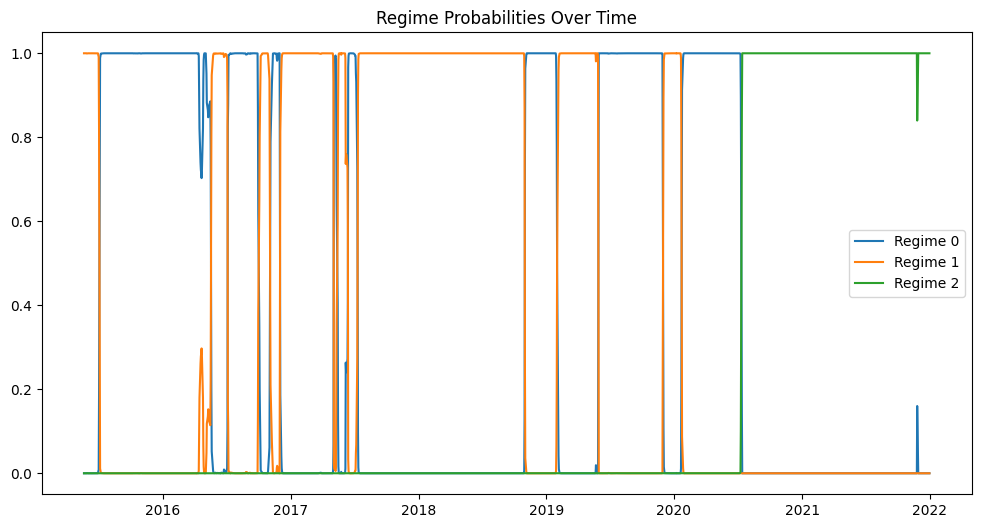

In [167]:
plt.figure(figsize=(12, 6))

for i in range(3):
    plt.plot(train_df.index, train_probs[:, i], label=f"Regime {i}")

plt.title("Regime Probabilities Over Time")
plt.legend()
plt.show()

The histogram below shows the model's confidence in its regime assignments by plotting the maximum regime probability for each training observation.

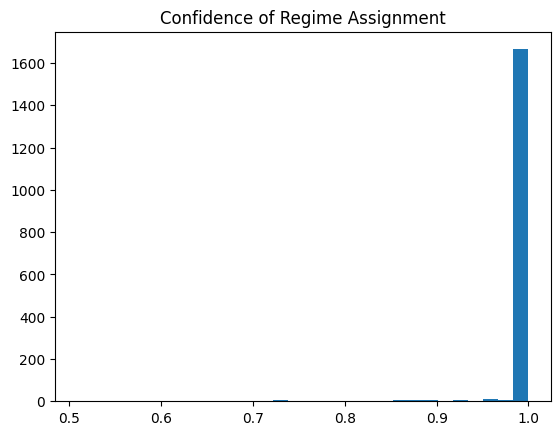

In [159]:
max_probs = train_probs.max(axis=1)

plt.hist(max_probs, bins=30)
plt.title("Confidence of Regime Assignment")
plt.show()

## 15. Check Regime Distribution by Year

This diagnostic shows how regime assignments vary over time. A useful regime model should show persistence and changes across market environments rather than assigning every year to the same state.

In [161]:
full_check = pd.concat([
    train_df.reset_index().assign(split="train"),
    val_df.reset_index().assign(split="val"),
    test_df.reset_index().assign(split="test")
])

full_check["year"] = full_check["Date"].dt.year

regime_by_year = pd.crosstab(full_check["year"], full_check["regime"], normalize="index")
regime_by_year_counts = pd.crosstab(full_check["year"], full_check["regime"])

display(regime_by_year_counts)
display(regime_by_year)

regime,0,1,2
year,,,
2015,129,33,0
2016,184,80,0
2017,26,237,0
2018,43,221,0
2019,157,107,0
2020,123,17,124
2021,0,0,263
2022,181,42,42
2023,144,120,0


regime,0,1,2
year,,,
2015,0.796296,0.203704,0.000000
2016,0.696970,0.303030,0.000000
2017,0.098859,0.901141,0.000000
2018,0.162879,0.837121,0.000000
2019,0.594697,0.405303,0.000000
2020,0.465909,0.064394,0.469697
2021,0.000000,0.000000,1.000000
2022,0.683019,0.158491,0.158491
2023,0.545455,0.454545,0.000000


## 16. Export HMM-Augmented Modeling Files

The final outputs are saved as CSV files and used by the downstream supervised prediction notebooks. Each file contains the original modeling variables plus the HMM regime label and regime probability features.

In [ ]:
# Create final HMM-augmented modeling files for downstream supervised models.
# These contain all original modeling variables plus the HMM regime label and regime probabilities.

train_final = train_df.copy()
val_final = val_df.copy()
test_final = test_df.copy()

print("Train final:", train_final.shape)
print("Validation final:", val_final.shape)
print("Test final:", test_final.shape)

print("\nRegime columns:")
print([col for col in train_final.columns if "regime" in col])

print("\nTarget check:")
print(train_final[["Price", "Target"]].isna().sum())
print(val_final[["Price", "Target"]].isna().sum())
print(test_final[["Price", "Target"]].isna().sum())

In [168]:
train_final.to_csv("train_final_weighted_hmm.csv", index=True)
val_final.to_csv("val_final_weighted_hmm.csv", index=True)
test_final.to_csv("test_final_weighted_hmm.csv", index=True)